In [1]:
import pandas as pd

In [2]:
data = pd.read_csv("weight-height.csv")

In [3]:
data.head()

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801


In [4]:
data.Gender.replace(['Male', 'Female'], [1,0], inplace=True)

C:\Users\amazo\AppData\Local\Temp\ipykernel_20280\4055341530.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data.Gender.replace(['Male', 'Female'], [1,0], inplace=True)


In [5]:
data.corr()

,Gender,Height,Weight
Gender,1.000000,0.691072,0.796723
Height,0.691072,1.000000,0.924756
Weight,0.796723,0.924756,1.000000


# Simple Linear Regression:
   - 1 input feature
### y = mx+b
### weight  = m(Height)+bias

In [7]:
X=data[['Height']]
y = data[['Weight']]

In [24]:
from sklearn.model_selection import train_test_split

# Split data: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [28]:
from sklearn.linear_model import LinearRegression
model  = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [29]:
model.coef_

array([[7.70218561]])

In [30]:
model.intercept_

array([-349.78782058])

# Weight = 7.70 (Height) + (-349.78)

In [31]:
y_pred_train =  model.predict(X_train)

In [32]:
from sklearn.metrics import mean_squared_error, r2_score

In [34]:
from math import sqrt
sqrt(mean_squared_error(y_train, y_pred_train))

12.221853323000888

In [35]:
r2_score(y_train, y_pred_train)

0.8545053200451038

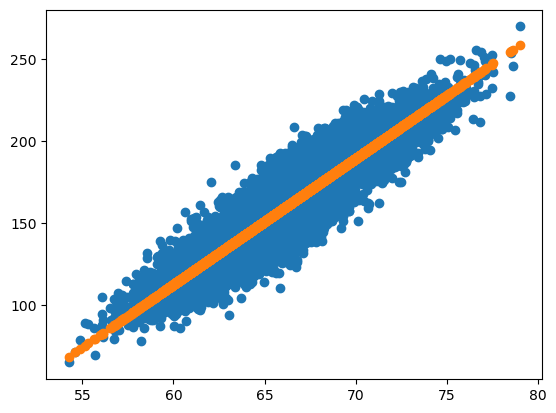

In [38]:
import matplotlib.pyplot as plt
plt.scatter(x=X_train, y=y_train)
plt.scatter(x=X_train, y=y_pred_train)
plt.savefig('plot.png')

In [39]:
y_pred_test = model.predict(X_test)

In [40]:
sqrt(mean_squared_error(y_test, y_pred_test))

12.206699153994379

In [42]:
r2_score(y_test, y_pred_test)

0.8577317776680295

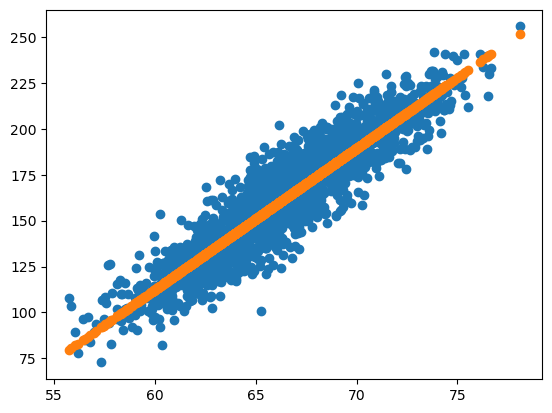

In [43]:
import matplotlib.pyplot as plt
plt.scatter(x=X_test, y=y_test)
plt.scatter(x=X_test, y=y_pred_test)
plt.savefig('plot_test.png')

# Overfitting: 
   Difference (Gap) between training and testing accuracy

### Underfit : Performace low on training data    Performance low on testing data
### Overfit  : Performace high on training data   Performance low on testing data
### BestFit  : Performace high on training data   Performance high on testing data

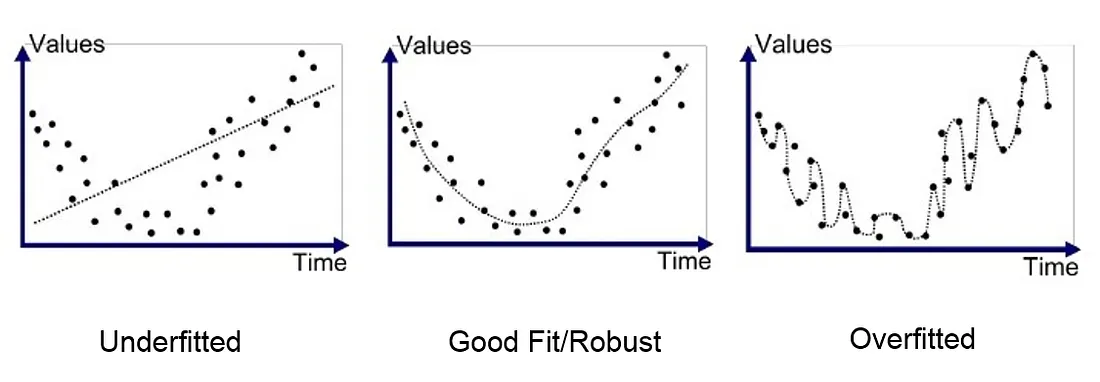

# Multiple Linear Regression
   - Input wll be more than 1

   - Y = m1X1 + m2X2 + c

In [44]:
data.head(3)

,Gender,Height,Weight
0,1,73.847017,241.893563
1,1,68.781904,162.310473
2,1,74.110105,212.740856


# Weight = W1(Gender) + W2(Height) + Bias

In [46]:
X= data.drop('Weight',axis=1)
X= data[['Gender', 'Height']]
y = data.Weight

In [47]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [48]:
model  = LinearRegression()

In [49]:
model.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [50]:
model.coef_

array([19.34720343,  5.97314123])

In [51]:
model.intercept_

np.float64(-244.69356793246453)

# Weight = 19.34720343(Gender) + 5.97314123(Height) + 244.69356793246453 

In [52]:
y_pred_train = model.predict(X_train)

In [53]:
r2_score(y_train, y_pred_train)

0.902590484928644